In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

In [9]:
class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [10]:
def raund(x):
    return np.round(x / 128)

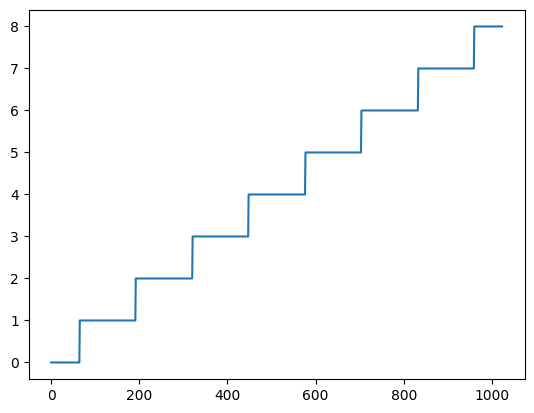

In [33]:
x = np.arange(0, 1024, 1)

y = raund(x)

plt.plot(x, y)

In [35]:
c = Chebyshev(0, 1024, 2001, raund)

0.7613796505837618

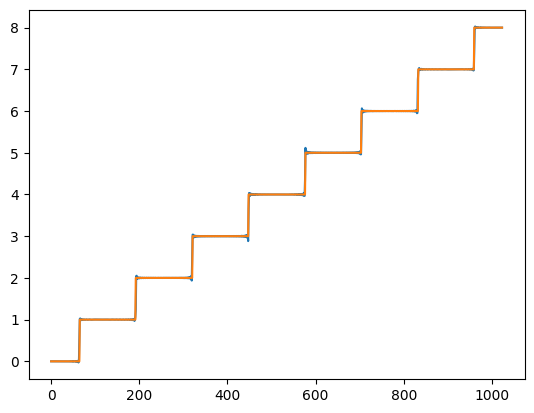

In [36]:
x = np.arange(0, 1024, 1)

y_poly = np.vectorize(c.eval)(x)

plt.plot(x, y_poly)

plt.plot(x, y)

max(abs(y - y_poly))

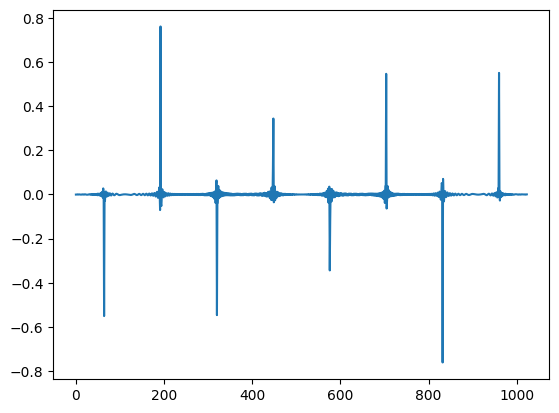

In [37]:
plt.plot(y - y_poly)

In [38]:
def polylut():
    N = 2048
    seq = np.array([np.round(i/128.0) for i in range(N)], dtype=float)
    c = np.fft.fft(seq)  

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

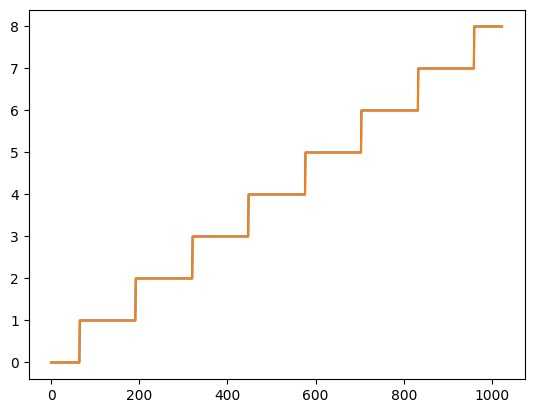

In [40]:
x = np.arange(0, 1024, 1)

y_lut = np.vectorize(polylut())(x)

plt.plot(x, y_lut)

plt.plot(x, y)

In [55]:
c = Chebyshev(0, 1024, 3487, polylut())

7.58859641791787e-12

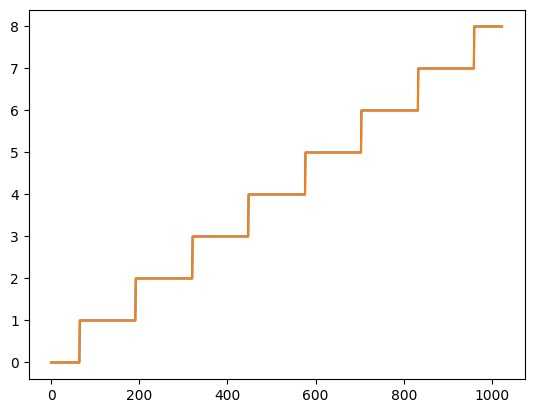

In [56]:
x = np.arange(0, 1024, 1)

y_polylut = np.vectorize(c.eval)(x)

plt.plot(x, y_polylut)

plt.plot(x, y)

max(abs(y - y_polylut))

---

Trim bits

In [57]:
def fun(x):
    return 1/(1 + np.exp(-8 * x))


In [62]:
c = Chebyshev(-8192, 8192, 4001, fun)

/var/folders/f4/cjlhwcw50v97ltsgj1fxyssm0000gn/T/ipykernel_43685/1434823236.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-8 * x))


/var/folders/f4/cjlhwcw50v97ltsgj1fxyssm0000gn/T/ipykernel_43685/1434823236.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-8 * x))


0.3209924671700677

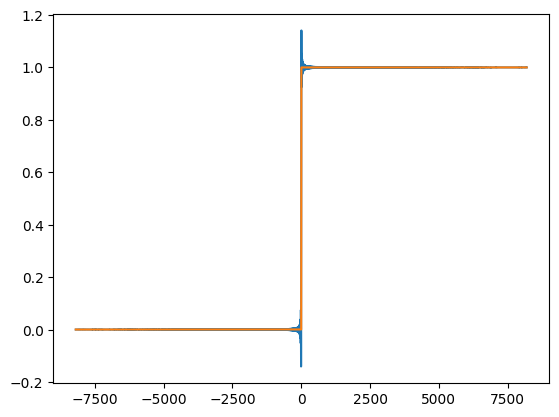

In [63]:
x = np.arange(-8192, 8192, 1)

y_poly = np.vectorize(c.eval)(x)

plt.plot(x, y_poly)

y = fun(x)

plt.plot(x, y)

max(abs(y - y_poly))